In [130]:
# Load functions
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import math

from osa import OSA
import time
import numpy as np
import matplotlib.pyplot as plt
import wshelper as wsh
import calibration
from wsapi import * 

#saving to latex pdf
plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "font.family": "serif",
    "text.usetex": True,
    "pgf.preamble": r"\usepackage{amsmath}",
})

def nearest_tenth(x):
    return math.ceil(x * 10) / 10

def create_connect_waveshaper():
    wsh.createWS('./WS200224_4x16.wsconfig')
    wsh.connect()

def disconnect_delete_waveshaper():
    wsh.disconnect()
    wsh.deleteWS()

def apply_waveshaper_profile(comblines, peaks, phases, channels, delta_l=0.1, sigma=0.005, plot = False):
    """
    Function to apply a waveshaper profile based on the input parameters.

    Parameters:
    - comblines: List of center frequencies for the Gaussian signals.
    - peaks: List of peak amplitudes for the Gaussian signals.
    - phases: List of phases for the Gaussian signals.
    - channels: List of channel assignments for each signal.
    - delta_l: Offset for frequency range. Default is 0.4.
    - sigma: Standard deviation for Gaussian function. Default is 0.008.
    """
    
    # Step 1: Precompute THz values for comblines and precompute bounds for each combline
    combline_thz = [wsh.nm2thz(combline) for combline in comblines] 
    rang_min = [wsh.nm2thz(combline - delta_l) for combline in comblines]
    rang_max = [wsh.nm2thz(combline + delta_l) for combline in comblines]
    
    # Step 2: Calculate the overall frequency range in THz only once
    rang = (wsh.nm2thz(min(comblines)-0.3), wsh.nm2thz(max(comblines)+0.3))
    rang = (round(rang[0], 3), round(rang[1], 3))

    # Step 3: Generate the signal profile for each combline
    signal = tuple(
        wsh.BoundFunc(
            wsh.gaussian(mu=comb_thz, peak=peak, phase=phase, sigma=sigma),
            max_r, min_r, channel
        )
        for comb_thz, peak, phase, channel, min_r, max_r 
        in zip(combline_thz, peaks, phases, channels, rang_min, rang_max)
    )
    #print(f'the peaks are: {peaks}')
    
    # Step 4: Compose the profile
    new_profile = wsh.compose_func((0, 0, 0), rang[1], rang[0], 1e-3, *signal)
    
    # Step 5: Plot the generated attenuation profile
    if plot == True:        
        plt.plot(wsh.nm2thz(new_profile[:, 0]), -new_profile[:, 1])
        plt.xlabel('Wavelength (nm)')
        plt.ylabel('Attenuation')
        plt.title('Generated Profile')
        plt.show()

    # Step 6: Apply profile to waveshaper    
    wsh.apply_profile(new_profile)





#TODO? add phase matching data if necessary
def physical_model(coefficients, phases, noise_rate=0.0):
    
    if noise_rate > 0:
        #noise rate is a fraction of the mean absolute value of coefficients and phases, so that the noise scales with the signal
        coefficients = coefficients + torch.randn_like(coefficients) * (noise_rate * coefficients.abs().mean())
        phases = phases + torch.randn_like(phases) * (noise_rate * phases.abs().mean())
    
    
    N = coefficients.size(0)
  
    # convert intensities to amplitudes
    coefficients = torch.sqrt(coefficients)
    intensity = torch.zeros((2 * N - 1), dtype=torch.float, device=coefficients.device)
    for gamma in range(1, 2 * N): #2n-1 outputs
        alpha = torch.arange(max(1, gamma-N+1), min(N, gamma) + 1, 1, device=coefficients.device)
        
        # we do a lot of redundant calculation. I briefly tried cutting the summation in half but it gives weird results
        # alpha = torch.arange(max(1, gamma-N+1), (gamma + 1) // 2 + 1, 1, device=coefficients.device)

        
        terms = coefficients[alpha - 1] * coefficients[gamma - alpha] * torch.exp(1j * (phases[alpha - 1] + phases[gamma - alpha]))

        intensity[gamma - 1] = terms.sum().abs() ** 2
    
    # we need to scale the resultant intensities relative to the max if all comblines are 100% and in phase,
    # to get the same scale of values as measurement, i.e. [0, 1]
    intensity = intensity / N ** 2




    if noise_rate > 0:
        noise = torch.randn_like(intensity) * (noise_rate * intensity.abs().mean())
        #print(f"Adding intensity noise {noise}")
        intensity = torch.abs(intensity + noise)

    return intensity

import os

def create_folders(name):
    base_path = os.path.join("data_runs", name)
    stability_path = os.path.join(base_path, "stability")
    checkpoints_path = os.path.join(base_path, "checkpoints")
    traces_path = os.path.join(base_path, "traces")
    boundaries_path = os.path.join(base_path, "boundaries")

    os.makedirs(stability_path, exist_ok=True)
    os.makedirs(checkpoints_path, exist_ok=True)
    os.makedirs(traces_path, exist_ok=True)
    os.makedirs(boundaries_path, exist_ok=True)

    print(f"Folders ensured:\n- {stability_path}\n- {checkpoints_path}\n- {traces_path}\n- {boundaries_path}")


In [40]:
osa.close_connection()

Connection closed


In [75]:
SPEED_OF_LIGHT = 299792458/1
n_comblines = 50
comblines_ranges = np.array([
    np.arange(0, 5),
    np.arange(11, 16),
    np.arange(34, 39),
    np.arange(45, 50)
])
n_bands = comblines_ranges.shape[0]
band_size = comblines_ranges.shape[1]

# separation_comblines = 0.2
combline_freq_separation = 25 #GHZ
initial_wl = 1551.107
# initial_wl = 1543.795
initial_freq = SPEED_OF_LIGHT/initial_wl
freqs = np.arange(initial_freq, initial_freq - n_comblines * combline_freq_separation, -combline_freq_separation)

# comblines = np.arange(initial_wl, initial_wl + n_comblines * separation_comblines, separation_comblines)
comblines = SPEED_OF_LIGHT/freqs
#get array of expected SHG wavelengths
target_freqs = np.sort(np.unique(np.add.outer(freqs, freqs)))[::-1]
targets = SPEED_OF_LIGHT/target_freqs * 1e-9# + 0.014e-9
print(f"combline wavelenths: {comblines}")
print(f"SHG wavelengths: {targets}")

combline wavelenths: [1551.107      1551.30765916 1551.50837025 1551.70913328 1551.90994828
 1552.11081526 1552.31173424 1552.51270525 1552.7137283  1552.91480342
 1553.11593062 1553.31710992 1553.51834136 1553.71962493 1553.92096068
 1554.12234861 1554.32378874 1554.5252811  1554.72682571 1554.92842259
 1555.13007175 1555.33177323 1555.53352703 1555.73533318 1555.9371917
 1556.13910261 1556.34106593 1556.54308167 1556.74514987 1556.94727055
 1557.14944371 1557.35166938 1557.55394759 1557.75627835 1557.95866169
 1558.16109761 1558.36358616 1558.56612733 1558.76872117 1558.97136768
 1559.17406688 1559.37681881 1559.57962347 1559.78248089 1559.98539108
 1560.18835408 1560.3913699  1560.59443856 1560.79756008 1561.00073448]
SHG wavelengths: [7.75553500e-07 7.75603662e-07 7.75653830e-07 7.75704004e-07
 7.75754185e-07 7.75804373e-07 7.75854567e-07 7.75904767e-07
 7.75954974e-07 7.76005188e-07 7.76055408e-07 7.76105634e-07
 7.76155867e-07 7.76206107e-07 7.76256353e-07 7.76306605e-07
 7.76356

# Intensity Calibration

192.168.10.85 is reachable, Connected to OSA
Successfully login!
Creating waveshaper...   duplicate name, instance name already exist.
Connecting to waveshaper...   success
Applying profile...   success
Sweep complete.


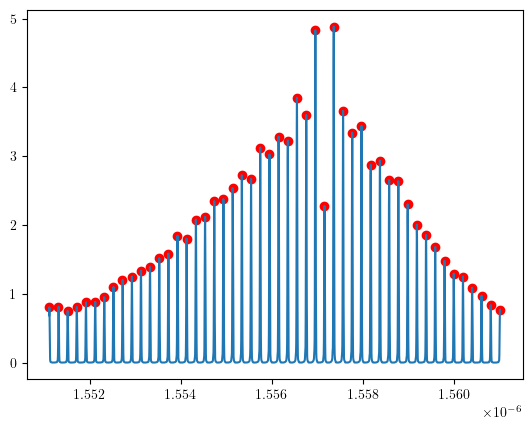

Applying profile...   success
Sweep complete.


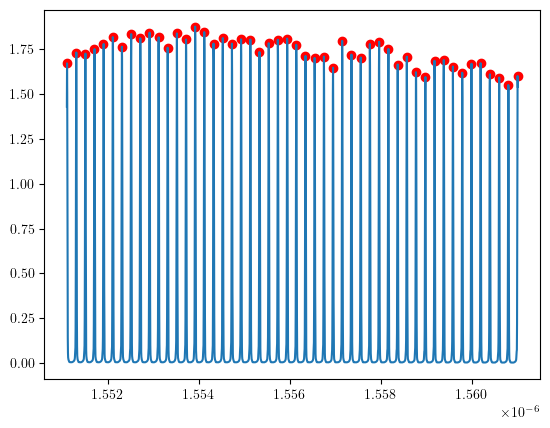

Applying profile...   success
Sweep complete.


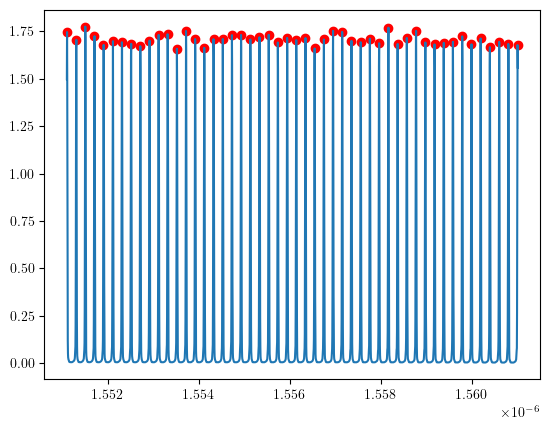

Relative combline intensities: [1.09028378 1.14273629 1.05157581 1.14826247 1.26458649 1.30113796
 1.36028446 1.63599744 1.76403055 1.86405262 1.96648344 1.9802046
 2.26209114 2.31597782 2.8007578  2.69421848 3.00083995 3.11099357
 3.38626622 3.47637226 3.70582168 3.82621073 3.85617789 4.56169481
 4.43185414 4.7221954  4.47637724 5.30452465 4.97993415 6.44216929
 3.31296489 6.80167108 5.04715557 4.81392314 4.99269183 4.07810563
 3.95830175 3.67152003 3.46484658 2.97095916 2.73836928 2.5394432
 2.25231583 1.94185649 1.75006821 1.69337027 1.42149071 1.25589891
 1.04880674 1.        ]


In [ ]:
# Connect OSA directly to waveshaper output (NOT SHG)
# Measures relative combline powers, so we can adjust peaks to get them even
host = '192.168.10.85'  # OSA IP address
port = 10001            # OSA port number
osa = OSA(host, port)
osa.connect()
response = osa.autenticate()
create_connect_waveshaper()
peaks = np.ones(n_comblines)*.1
phases = np.zeros(n_comblines)
channels = np.ones(n_comblines)
relative_combline_intensities = np.ones(n_comblines)
N_revisions=2
for i in range(N_revisions+1):
    apply_waveshaper_profile(comblines, peaks / relative_combline_intensities, phases, channels, plot = False, delta_l=0.05, sigma=0.005)
    wavelengths, power = osa.perform_measurement_OSA((np.max(comblines)+np.min(comblines))/2, nearest_tenth((np.max(comblines)-np.min(comblines))*1.0), 5000, sensitivity = "high1", resolution = 0.02)
    combline_indices = [np.argmin(np.abs(wavelengths - combline*1e-9)) for combline in comblines]
    radius = (combline_indices[1] - combline_indices[0])//2

    combline_intensities = np.array([
        np.array(power)[max(0, i-radius):min(len(power), i+radius)-1].max()
        for i in combline_indices
    ])

    plt.plot(wavelengths, power)
    plt.scatter(np.array(wavelengths)[combline_indices], combline_intensities, color="red")
    plt.show()

    if i < N_revisions:
        relative_combline_intensities *= combline_intensities
        relative_combline_intensities /= np.min(relative_combline_intensities)

print(f"Relative combline intensities: {relative_combline_intensities}")

# Phase and Normalization

In [165]:
# Phase Alignment Calibration


# === Instantiate and connect OSA ===
host = '192.168.10.85'  # OSA IP address
port = 10001            # OSA port number
osa = OSA(host, port)
osa.connect()
response = osa.autenticate()
create_connect_waveshaper()


channels = np.ones(n_comblines)
phase_offsets = np.zeros(n_comblines)

def find_phase_offset(test_combline, static_comblines, spike_wavelength, detail, center_phase=0, range=2*np.pi):
    peaks = np.zeros(n_comblines)
    peaks[test_combline] = 1
    peaks[static_comblines] = 1
    spike_index = None
    

    #looking for destructive rather than constructive terms gives greater accuracy
    lowest_intensity = np.inf
    worst_phase = 0

    for phase in np.linspace(center_phase - range/2, center_phase + range/2, detail, endpoint=(range<2*np.pi)):
        phase_offsets[test_combline] = phase
        apply_waveshaper_profile(comblines, peaks / relative_combline_intensities, phase_offsets, channels, plot = False, delta_l=0.05, sigma=0.005)
        wavelengths, power = osa.perform_measurement_OSA(spike_wavelength*1e9, 0.2, 2, sensitivity = "high2", resolution = 0.02)

        if spike_index == None: 
            spike_index = np.argmin(np.abs(wavelengths - spike_wavelength))
        spike_intensity = power[spike_index]
        print(f"Phase {phase:.2f} rad: Spike intensity = {spike_intensity}")

        if spike_intensity < lowest_intensity:
            lowest_intensity = spike_intensity
            worst_phase = phase


    if range < 2*np.pi:
        phase_offsets[test_combline] = worst_phase + np.pi
    else:
        print(f"---Searching around {worst_phase:.2f} rad---")
        find_phase_offset(test_combline, static_comblines, spike_wavelength, detail, center_phase=worst_phase, range=range/detail)


#start inclusive, end exclusive
from itertools import product
def find_phases_for_range(start, end, res, mode=2):
    
# Here we have two methods for calibrating a range of comblines. The first one ensures adjacent comblines are well-calibrated,
# but global consistency suffers as errors add up across bigger ranges. The second gives slightly better performance if stronger intraband
# SHG is needed, but phases between adjacent comblines are less consistent. 

    if mode == 1:



        for i in range(start + 2, end):
                find_phase_offset(i, [start, start+1, i-1], targets[start+i], (10 if res=="high" else 5))
                print(f"-----Best phase for combline {i} is {phase_offsets[i]}-----     {(i - start - 1) / (end - start - 2) * 100:.1f}%")



    else:


        calibrated = np.array([start, start + 1])
        steps = 0
        while calibrated.size < end - start:
            # Here we do a sort of breadth first search, using the currently calibrated comblines to calibrate all other possible
            # comblines (including non-adjacent ones) with a single step. This ensures the fewest number of steps, and thus least accumulated error, to calibrate all comblines
            steps += 1
            for reference_1, reference_2, reference_3 in product(calibrated, repeat=3):

                tester = reference_1 + reference_2 - reference_3 
                if tester not in calibrated and tester >= start and tester < end:
                    print(f"Finding {tester} with references {reference_1}, {reference_2}, {reference_3}; {steps} step(s)")
                    # target_idx = min(tester, reference_1, reference_2, reference_3) + max(tester, reference_1, reference_2, reference_3)
                    target_idx = reference_1 + reference_2
                    find_phase_offset(tester, [reference_1, reference_2, reference_3], targets[target_idx], (10 if res=="high" else 5))
                    calibrated = np.append(calibrated, tester)
                    print(f"-----Best phase for combline {tester} is {phase_offsets[tester]}-----     {(calibrated.size - 2) / (end - start - 2) * 100:.1f}%")



for i, comblines_range in enumerate(comblines_ranges):
    find_phases_for_range(comblines_range[0], comblines_range[-1]+1, res="high")
    print(f"-------------------{i+1}/{n_bands} Bands Complete-------------------")

phase_offsets = (phase_offsets - phase_offsets[0] + np.pi) % (2 * np.pi) - np.pi
print(f"Phase offsets: {phase_offsets}")


192.168.10.85 is reachable, Connected to OSA
Successfully login!
Creating waveshaper...   duplicate name, instance name already exist.
Connecting to waveshaper...   success
Finding 2 with references 1, 1, 0; 1 step(s)
Applying profile...   success
Sweep complete.
Phase -3.14 rad: Spike intensity = 2.30857382e-06
Applying profile...   success
Sweep complete.
Phase -2.51 rad: Spike intensity = 3.64555346e-06
Applying profile...   success
Sweep complete.
Phase -1.88 rad: Spike intensity = 6.73606444e-06
Applying profile...   success
Sweep complete.
Phase -1.26 rad: Spike intensity = 8.8299003e-06
Applying profile...   success
Sweep complete.
Phase -0.63 rad: Spike intensity = 1.29436348e-05
Applying profile...   success
Sweep complete.
Phase 0.00 rad: Spike intensity = 1.3543443e-05
Applying profile...   success
Sweep complete.
Phase 0.63 rad: Spike intensity = 1.32494297e-05
Applying profile...   success
Sweep complete.
Phase 1.26 rad: Spike intensity = 1.23068508e-05
Applying profile...

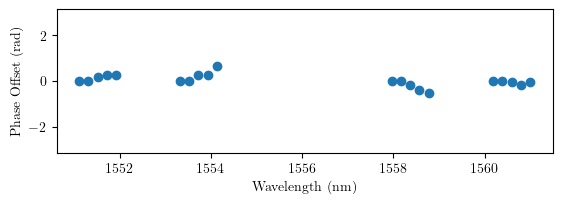

In [166]:

for comblines_range in comblines_ranges:
    plt.scatter(comblines[comblines_range], phase_offsets[comblines_range], color='tab:blue')
plt.ylim(-np.pi, np.pi)
plt.ylabel('Phase Offset (rad)')
plt.xlabel('Wavelength (nm)')
plt.gca().set_aspect('0.5')
# np.savez("phase_offsets.npz", comblines=comblines, phase_offsets=phase_offsets)
# plt.savefig("phase_offsets.pdf", bbox_inches='tight')

In [63]:
phase_offsets = np.zeros(n_comblines)

192.168.10.85 is reachable, Connected to OSA
Successfully login!
Creating waveshaper...   duplicate name, instance name already exist.
Connecting to waveshaper...   success


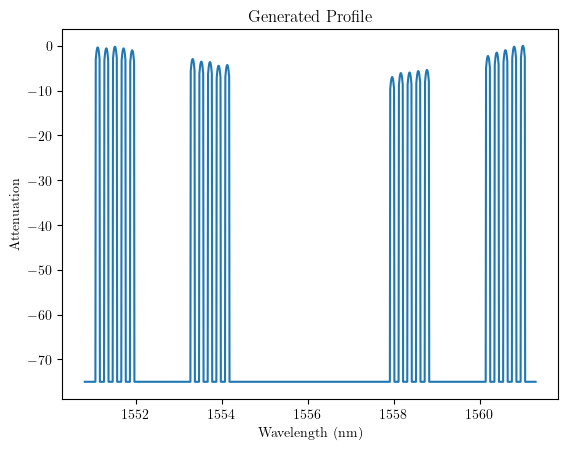

Applying profile...   success
Sweep complete.


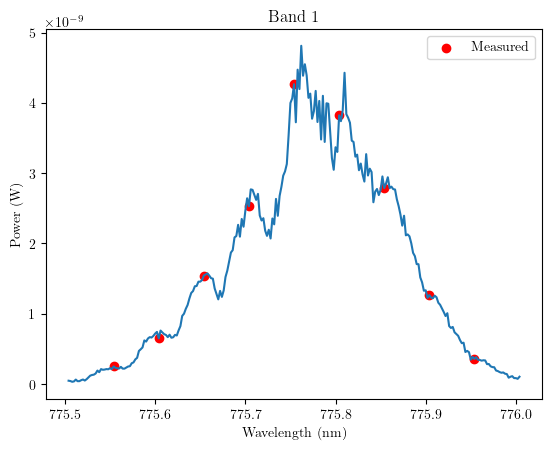

Sweep complete.


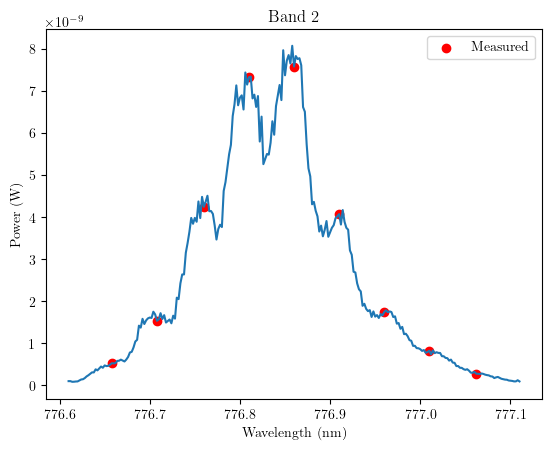

Sweep complete.


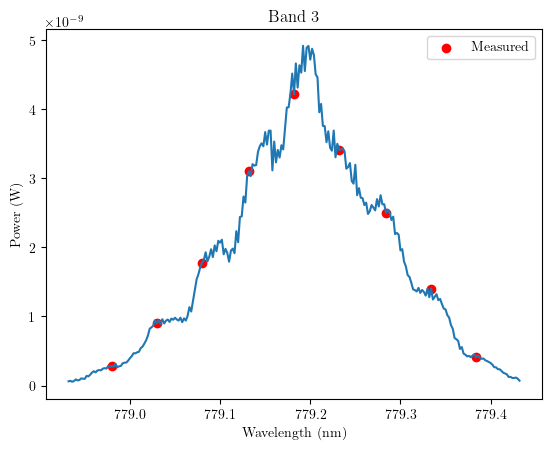

Sweep complete.


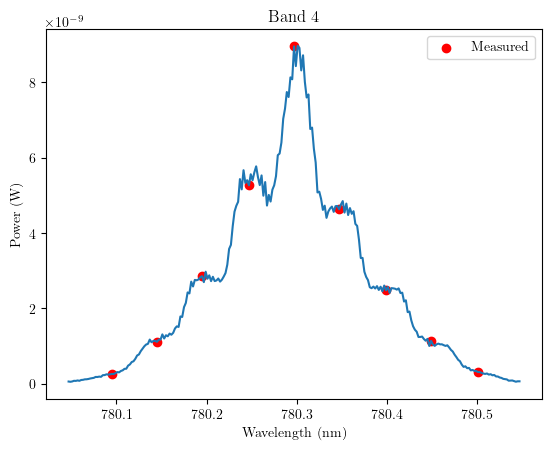

In [184]:
# Connecting to the OSA and Waveshaper, verifying correct behaviour


# === Instantiate and connect OSA ===
host = '192.168.10.85'  # OSA IP address
port = 10001            # OSA port number
osa = OSA(host, port)
osa.connect()
response = osa.autenticate()
create_connect_waveshaper()


peaks = np.zeros(n_comblines)*1
peaks[comblines_ranges] = 1

phases = np.zeros(n_comblines)
channels = np.ones(n_comblines)

apply_waveshaper_profile(comblines, peaks / relative_combline_intensities, phases + phase_offsets, channels, plot = True, delta_l=0.05, sigma=0.005)



# targets_A = targets[2*comblines_range_A[0]:2*comblines_range_A[-1]+1]
# targets_B = targets[2*comblines_range_B[0]:2*comblines_range_B[-1]+1]
bands_targets = np.array([targets[2*comblines_range[0]:2*comblines_range[-1]+1] for comblines_range in comblines_ranges]) 
shg_indices = np.empty((n_bands, 2*band_size-1), dtype=int)
normalization = torch.empty(n_bands, dtype=torch.float, device='cpu')



for i, band_targets in enumerate(bands_targets):
    wavelengths, power = osa.perform_measurement_OSA((np.max(band_targets)+np.min(band_targets))/2*1e9, nearest_tenth((np.max(band_targets)-np.min(band_targets))*1e9), 0.1, sensitivity = "high2", resolution = 0.02)
    normalization[i] = np.max(power)
    shg_indices[i] = [np.argmin(np.abs(wavelengths - t)) for t in band_targets]



    plt.plot(1e9*np.array(wavelengths), 1e-3*np.array(power))#m to nm, mW to W
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Power (W)')
    plt.title(f'Band {i+1}')
    plt.scatter(1e9*np.array(wavelengths)[shg_indices[i]], 1e-3*np.array(power)[shg_indices[i]], color='red', label='Measured')
    plt.legend()
    plt.show()



In [126]:
print(bands_targets)
print((bands_targets[3,8]+bands_targets[3,0])/2)

[[7.75553500e-07 7.75603662e-07 7.75653830e-07 7.75704004e-07
  7.75754185e-07 7.75804373e-07 7.75854567e-07 7.75904767e-07
  7.75954974e-07]
 [7.76658555e-07 7.76708860e-07 7.76759171e-07 7.76809488e-07
  7.76859812e-07 7.76910143e-07 7.76960480e-07 7.77010824e-07
  7.77061174e-07]
 [7.78979331e-07 7.79029937e-07 7.79080549e-07 7.79131168e-07
  7.79181793e-07 7.79232425e-07 7.79283064e-07 7.79333709e-07
  7.79384361e-07]
 [7.80094177e-07 7.80144928e-07 7.80195685e-07 7.80246449e-07
  7.80297219e-07 7.80347996e-07 7.80398780e-07 7.80449570e-07
  7.80500367e-07]]
7.802972721404139e-07


# Training
In general, np arrays and tensors use dimension 0 to specify the band

In [168]:
# Load datasets
from sklearn.datasets import make_circles, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
import imageio  # Import the imageio library

# ===== MODEL A: make_moons dataset =====
# Step 1: Generate the make_moons dataset
X, y = make_moons(n_samples=70*n_bands, noise=0.15, random_state=42)

# Step 2: Scale the dataset to the range [0, 1]
X_min = np.min(X, axis=0)
X_max = np.max(X, axis=0)
X_scaled_0_1 = (X - X_min) / (X_max - X_min)

# Step 3: Scale the dataset to the range [-1, 1]
X_scaled_neg1_1 = 2 * X_scaled_0_1 - 1

# Step 4: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled_neg1_1, y, test_size=0.5, random_state=42)

# Step 5: Convert the data to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)


In [169]:
# Waveshaper layer

class WaveshaperLayer(nn.Module):
    def __init__(self, osa, comblines, channels):#, delta_l=0.1, sigma=0.005):
        super(WaveshaperLayer, self).__init__()
        
        self.osa = osa
        self.comblines = comblines
        self.channels = channels


        self.intensities = torch.zeros((2 * n_comblines + 1), dtype=torch.float)
        

        
    def performOSASweep(self, peaks, phi, normalization):
        # Generate signal profile for each combline
        apply_waveshaper_profile(self.comblines, peaks.detach() / relative_combline_intensities, phi.detach(), self.channels)


        #do smaller OSA sweep for each band to save time
        for i in range(n_bands):
            wavelengths, power = self.osa.perform_measurement_OSA((np.max(bands_targets[i])+np.min(bands_targets[i]))/2*1e9, nearest_tenth((np.max(bands_targets[i])-np.min(bands_targets[i]))*1e9), normalization[i]*1e3, sensitivity = "high2", resolution = 0.02)
            self.intensities[comblines_ranges[i,0]*2:comblines_ranges[i,-1]*2+1] = torch.tensor(power, dtype=torch.float)[shg_indices[i]] / normalization[i]




    def forward(self, startCombline, endCombline):    
        # Return sliced tensor of intensities, from 2*startCombline to 2*endCombline inclusive
        return self.intensities[2*startCombline:2*endCombline+1]
    

In [170]:
from pat import make_pat_func
host = '192.168.10.85'  # OSA IP address
port = 10001            # OSA port number
osa = OSA(host, port)
osa.connect()
response = osa.autenticate()
create_connect_waveshaper()
channels = np.ones(n_comblines)

# Create the layer and pass input peaks
layer = WaveshaperLayer(osa, comblines=comblines, channels=channels)



class Dual_Physical_NN_SHG(nn.Module):
    
    def __init__(self):
        super(Dual_Physical_NN_SHG, self).__init__()


        self.fc1 = nn.Linear(X_train.size(1), band_size)
        self.phase_parameter = nn.Parameter(torch.randn(band_size))
        self.ln = nn.LayerNorm(2*band_size-1)
        self.fc2 = nn.Linear(2 * band_size - 1, 1)

        nn.init.normal_(self.fc1.weight, mean=0.0, std=0.6)
        nn.init.constant_(self.fc1.bias, 0)
        nn.init.normal_(self.fc2.weight, mean=0.0, std=0.6)
        nn.init.constant_(self.fc2.bias, 0)


        #physical model gets intensities and phases, layer.forward just retrieves OSA data for a combline range
        def make_pat(startCombline, endCombline):
            return make_pat_func((lambda intensity, phase: layer.forward(startCombline, endCombline)), physical_model)

    
        self.pat_layers = [make_pat(comblines_range[0], comblines_range[-1]) for comblines_range in comblines_ranges]

    def forward(self, x, normalization):

        full_peaks = torch.zeros(n_comblines, dtype=x.dtype, device=x.device)
        full_phases = torch.zeros(n_comblines, dtype=x.dtype, device=x.device)
        band_intensities = torch.empty((n_bands, band_size), dtype=x.dtype, device=x.device)
        band_phases = torch.empty((n_bands, band_size), dtype=x.dtype, device=x.device)
        for i in range(n_bands):


            intermediate = self.fc1(x[i])

            
            #print(f"The input of pat {xA}, {xB}")
            pi_phase = torch.where(intermediate < 0, torch.tensor(np.pi, device=x.device), torch.tensor(0.0, device=x.device))

            intermediate = torch.abs(intermediate)
   

            intermediate = intermediate / intermediate.max().clamp(min=1e-5)

            full_peaks[comblines_ranges[i]] = intermediate
            full_phases[comblines_ranges[i]] = self.phase_parameter * intermediate + pi_phase

            band_intensities[i] = intermediate
            band_phases[i] = self.phase_parameter * intermediate + pi_phase

        
        #perform SHG and OSA measurement. Results are stored internally in waveshaper layer
        layer.performOSASweep(full_peaks, full_phases, normalization)
        predictions = torch.empty((n_bands, 1), dtype=x.dtype, device=x.device)

        for i in range(n_bands):
            #perform PAT for each band. Forward it just retrieves the relevant slice of the OSA measurement
            out = self.pat_layers[i](band_intensities[i], band_phases[i])

            #ln and fc
            out = self.ln(out)
            predictions[i] = self.fc2(out)

        return predictions


192.168.10.85 is reachable, Connected to OSA
Successfully login!
Creating waveshaper...   duplicate name, instance name already exist.
Connecting to waveshaper...   success


In [137]:
print(normalization)

tensor([6.5939e-05, 9.8267e-05, 1.3206e-05, 8.0206e-05])


Folders ensured:
- data_runs\experiment_quad_02\stability
- data_runs\experiment_quad_02\checkpoints
- data_runs\experiment_quad_02\traces
- data_runs\experiment_quad_02\boundaries


C:\Users\jacka\AppData\Local\Temp\ipykernel_25524\3027717055.py:18: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  apply_waveshaper_profile(self.comblines, peaks.detach() / relative_combline_intensities, phi.detach(), self.channels)


Applying profile...   success
Sweep complete.
Sweep complete.
Sweep complete.
Sweep complete.
Class: 1.0; Output: -0.1791948527097702
Class: 1.0; Output: 0.6062541007995605
Class: 1.0; Output: 1.735654354095459
Class: 1.0; Output: 1.1408510208129883
...2%
Applying profile...   success
Sweep complete.
Sweep complete.
Sweep complete.
Sweep complete.
Class: 1.0; Output: 2.820824384689331
Class: 0.0; Output: 0.601955771446228
Class: 1.0; Output: 0.9496775269508362
Class: 0.0; Output: 0.7086970210075378
...5%
Applying profile...   success
Sweep complete.
Sweep complete.
Sweep complete.
Sweep complete.
Class: 0.0; Output: 2.733079671859741
Class: 0.0; Output: 1.660353183746338
Class: 0.0; Output: 2.7532341480255127
Class: 1.0; Output: 3.422121286392212
...8%
Applying profile...   success
Sweep complete.
Sweep complete.
Sweep complete.
Sweep complete.
Class: 0.0; Output: 0.05517040938138962
Class: 1.0; Output: 3.243413209915161
Class: 1.0; Output: 1.6928123235702515
Class: 0.0; Output: 2.3460

C:\Users\jacka\AppData\Local\Temp\ipykernel_25524\3027717055.py:18: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  apply_waveshaper_profile(self.comblines, peaks.detach() / relative_combline_intensities, phi.detach(), self.channels)


success
Sweep complete.
Sweep complete.
Sweep complete.
Sweep complete.
Class: 1.0; Output: -0.6020429730415344
Class: 0.0; Output: -1.7171521186828613
Class: 0.0; Output: -0.9014672636985779
Class: 0.0; Output: -1.696303129196167
...2%
Applying profile...   success
Sweep complete.
Sweep complete.
Sweep complete.
Sweep complete.
Class: 0.0; Output: -1.374847173690796
Class: 0.0; Output: -1.47087562084198
Class: 1.0; Output: 0.42248231172561646
Class: 1.0; Output: 0.7007796168327332
...5%
Applying profile...   success
Sweep complete.
Sweep complete.
Sweep complete.
Sweep complete.
Class: 1.0; Output: 0.6953352093696594
Class: 1.0; Output: 1.00265371799469
Class: 0.0; Output: 0.7067049145698547
Class: 1.0; Output: 0.4457707107067108
...8%
Applying profile...   success
Sweep complete.
Sweep complete.
Sweep complete.
Sweep complete.
Class: 1.0; Output: 0.24183347821235657
Class: 0.0; Output: -0.9376839995384216
Class: 1.0; Output: 0.5246984362602234
Class: 1.0; Output: 0.3472662568092346
.

...

Applying profile...   success
Sweep complete.
Sweep complete.
Sweep complete.
Sweep complete.
Class: 0.0; Output: -0.12867626547813416
Class: 1.0; Output: 2.7236196994781494
Class: 0.0; Output: 0.8174546957015991
Class: 0.0; Output: -1.6644227504730225
...2%
Applying profile...   success
Sweep complete.
Sweep complete.
Sweep complete.
Sweep complete.
Class: 1.0; Output: 1.4826853275299072
Class: 1.0; Output: 3.651944875717163
Class: 0.0; Output: -5.875305652618408
Class: 1.0; Output: 2.3701775074005127
...5%
Applying profile...   success
Sweep complete.
Sweep complete.
Sweep complete.
Sweep complete.
Class: 0.0; Output: -3.133758068084717
Class: 0.0; Output: -2.9459798336029053
Class: 1.0; Output: 2.4676425457000732
Class: 0.0; Output: -2.363895893096924
...8%
Applying profile...   success
Sweep complete.
Sweep complete.
Sweep complete.
Sweep complete.
Class: 0.0; Output: -4.141426086425781
Class: 1.0; Output: 2.2413485050201416
Class: 1.0; Output: 2.9580748081207275
Class: 0.0; Output

C:\Users\jacka\AppData\Local\Temp\ipykernel_25524\3027717055.py:18: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  apply_waveshaper_profile(self.comblines, peaks.detach() / relative_combline_intensities, phi.detach(), self.channels)


success
Sweep complete.
Sweep complete.
Sweep complete.
Sweep complete.
Class: 0.0; Output: -3.3774971961975098
Class: 0.0; Output: -6.686429977416992
Class: 0.0; Output: -5.1531548500061035
Class: 0.0; Output: -6.057502746582031
...2%
Applying profile...   success
Sweep complete.
Sweep complete.
Sweep complete.
Sweep complete.
Class: 0.0; Output: 0.1838112473487854
Class: 0.0; Output: -4.9667792320251465
Class: 0.0; Output: -8.301244735717773
Class: 1.0; Output: 3.959506034851074
...5%
Applying profile...   success
Sweep complete.
Sweep complete.
Sweep complete.
Sweep complete.
Class: 1.0; Output: 1.8001642227172852
Class: 1.0; Output: 3.597548484802246
Class: 1.0; Output: 3.5217275619506836
Class: 0.0; Output: -3.859168529510498
...8%
Applying profile...   success
Sweep complete.
Sweep complete.
Sweep complete.
Sweep complete.
Class: 1.0; Output: -0.8241384029388428
Class: 0.0; Output: -5.825140953063965
Class: 0.0; Output: -4.004024505615234
Class: 1.0; Output: 0.42314964532852173
.

C:\Users\jacka\AppData\Local\Temp\ipykernel_25524\3027717055.py:18: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  apply_waveshaper_profile(self.comblines, peaks.detach() / relative_combline_intensities, phi.detach(), self.channels)


Applying profile...   success
Sweep complete.
Sweep complete.
Sweep complete.
Sweep complete.
Class: 1.0; Output: 3.1355252265930176
Class: 1.0; Output: 2.610959053039551
Class: 1.0; Output: 4.355948448181152
Class: 0.0; Output: -4.104874610900879
...2%
Applying profile...   success
Sweep complete.
Sweep complete.
Sweep complete.
Sweep complete.
Class: 1.0; Output: 3.5939738750457764
Class: 0.0; Output: -6.034756183624268
Class: 0.0; Output: -3.6178133487701416
Class: 1.0; Output: 2.317298173904419
...5%
Applying profile...   success
Sweep complete.
Sweep complete.
Sweep complete.
Sweep complete.
Class: 0.0; Output: -4.936676025390625
Class: 0.0; Output: -4.403781890869141
Class: 1.0; Output: 4.627953052520752
Class: 0.0; Output: -4.76101016998291
...8%
Applying profile...   success
Sweep complete.
Sweep complete.
Sweep complete.
Sweep complete.
Class: 0.0; Output: -2.0277857780456543
Class: 0.0; Output: -5.177070140838623
Class: 1.0; Output: 3.8680617809295654
Class: 1.0; Output: 1.87

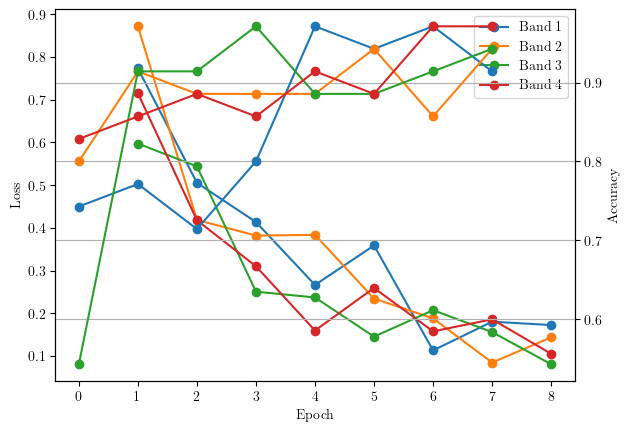

C:\Users\jacka\AppData\Local\Temp\ipykernel_25524\3990020670.py:49: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.2),
C:\Users\jacka\AppData\Local\Temp\ipykernel_25524\3990020670.py:50: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.arange(y_min, y_max, 0.2))
C:\Users\jacka\AppData\Local\Temp\ipykernel_25524\3027717055.py:18: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in 

Applying profile...   success
Sweep complete.
Sweep complete.
Sweep complete.
Sweep complete.
Applying profile...   success
Sweep complete.
Sweep complete.
Sweep complete.
Sweep complete.
Applying profile...   success
Sweep complete.
Sweep complete.
Sweep complete.
Sweep complete.
Applying profile...   success
Sweep complete.
Sweep complete.
Sweep complete.
Sweep complete.
Applying profile...   success
Sweep complete.
Sweep complete.
Sweep complete.
Sweep complete.
Applying profile...   success
Sweep complete.
Sweep complete.
Sweep complete.
Sweep complete.
Applying profile...   success
Sweep complete.
Sweep complete.
Sweep complete.
Sweep complete.
Applying profile...   success
Sweep complete.
Sweep complete.
Sweep complete.
Sweep complete.
Applying profile...   success
Sweep complete.
Sweep complete.
Sweep complete.
Sweep complete.
Applying profile...   success
Sweep complete.
Sweep complete.
Sweep complete.
Sweep complete.
Applying profile...   success
Sweep complete.
Sweep complete

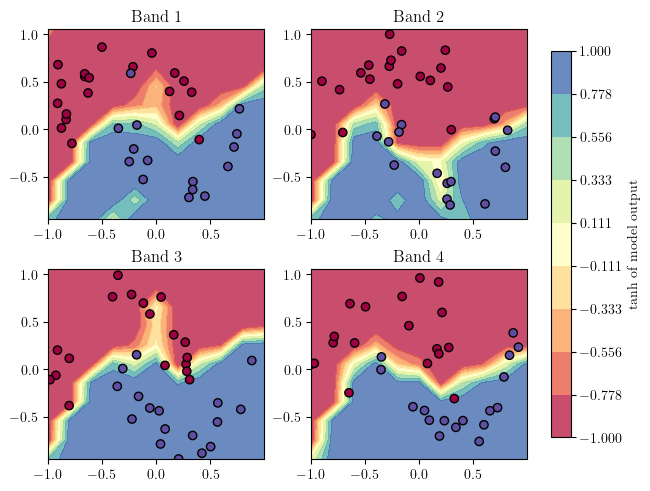

In [ ]:
name_of_experiment = "experiment_quad_02"  # Replace with your desired folder name
create_folders(name_of_experiment)
epochs = 8

# Convert y_train_A and y_train_B to have values 0 and 1 for binary classification
import json

y_train_binary = (y_train > 0).float()
y_test_binary = (y_test > 0).float()


def save_meshgrid_and_data(xx, yy, Z, X, y, model_name):
    """
    Save the meshgrid (xx, yy), decision boundary values (Z), and dataset (X, y) to a JSON file.
    
    Parameters:
        xx (np.ndarray): Meshgrid values for x-coordinates.
        yy (np.ndarray): Meshgrid values for y-coordinates.
        Z (np.ndarray): Decision boundary values corresponding to the meshgrid.
        X (torch.Tensor): Input dataset points.
        y (torch.Tensor): Labels corresponding to dataset points.
        model_name (str): Name of the model.
    """
    data_dict = {
        "meshgrid": {
            "x": xx.tolist(),
            "y": yy.tolist(),
            "z": Z.tolist()
        },
        "data_points": {
            "X": X.tolist(),
            "y": y.tolist()
        }
    }

    filename=f"./data_runs/{name_of_experiment}/meshgrid_data_{model_name}.json"

    with open(filename, "w") as f:
        json.dump(data_dict, f, indent=4)

    print(f"Meshgrid and data points saved to {filename}")

# this code gets pretty ugly, made worse when implementing multiple bands as an extra dimension
# if I get too many errors here it could be worth redoing the whole thing
def plot_decision_boundary(X_bands, y_bands, model, epoch, normalization, save_meshgrid = False):
    # Create meshgrids for both datasets
    x_min, x_max = X_bands[:,:, 0].min(), X_bands[:,:, 0].max() + 0.2
    y_min, y_max = X_bands[:,:, 1].min(), X_bands[:,:, 1].max() + 0.2
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.2),
                             np.arange(y_min, y_max, 0.2))
    

    
    grid = np.c_[xx.ravel(), yy.ravel()]
    # Add a band dimension so each band sees every point, while keeping point index first.
    grid = np.repeat(np.expand_dims(grid, axis=1), n_bands, axis=1)
    grid_tensor = torch.tensor(grid, dtype=torch.float32)
    
    Z = np.empty((grid_tensor.shape[0], n_bands))

    
    with torch.no_grad():
        # Evaluate both models together on their respective grids
        for point_idx in range(grid_tensor.shape[0]):
            out = model(grid_tensor[point_idx], normalization)
            Z[point_idx] = torch.tanh(out).squeeze(1)
        
    Z = Z.reshape(xx.shape + (n_bands,)).transpose(2, 0, 1)  # Reshape to (n_bands, xx.shape[0], xx.shape[1])


    # Save meshgrid and data points for both models
    if save_meshgrid:
        for i, Z_band in enumerate(Z):
            save_meshgrid_and_data(xx, yy, Z_band, X_bands[i], y_bands[i], f"Band_{i}")
    
    # Shared contour levels
    levels = np.linspace(Z.min(), Z.max(), 10)

    # Plotting with subplots - both models side by side
    fig, axes = plt.subplots(n_bands // 2, 2, constrained_layout=True)
    
    cf = None
    for i, ax in enumerate(axes.flat):
        cf = ax.contourf(xx, yy, Z[i], levels=levels, alpha=0.8, cmap=plt.cm.Spectral)
        ax.scatter(X_bands[i, :, 0], X_bands[i, :, 1], c=y_bands[i], edgecolors='k', cmap=plt.cm.Spectral)
        ax.set_title(f'Band {i+1}')

 
    cbar = fig.colorbar(
        cf,          # either cf1 or cf2 is fine since levels are identical
        ax=list(axes.ravel()),  # all axes
        shrink=0.9
        )
    cbar.set_label("tanh of model output")
    # plt.tight_layout()
    plt.savefig(f'./data_runs/{name_of_experiment}/boundaries/boundary_{epoch}.png')
    plt.show()

def train(model, X_train_bands, y_train_binary_bands, criterion, optimizer, epoch, loss_history, normalization):
    
    model.train()
    epoch_losses = np.zeros((n_bands, 1))
    for data in range(X_train_bands.shape[1]):
        optimizer.zero_grad()
        
        output = model(X_train_bands[:,data,:], normalization)
        loss = 0
        #TODO we sum together the band losses, and only perform 35 update steps. this could be artificially slowing convergence
        #Perhaps it would be better to either have a larger step size for more bands, or perform an optimizer step for each band
        for band in range(n_bands):
            print(f'Class: {y_train_binary_bands[band, data]}; Output: {output[band].item()}')
            band_loss = criterion(output[band], y_train_binary_bands[band, data].unsqueeze(0))
            epoch_losses[band][0] += band_loss.item()
            loss += band_loss
   
        loss.backward()
        optimizer.step()
        print(f"...{(data+1) * 100 // X_train_bands.shape[1]}%")

    avg_epoch_losses = epoch_losses / X_train_bands.shape[1]

    return np.append(loss_history, avg_epoch_losses, axis=1)
        

def test(model, X_test_bands, y_test_bands, normalization):

    predicted_classes = np.empty((n_bands, X_test_bands.shape[1]))
    with torch.no_grad():
        for data in range(X_test_bands.shape[1]):
            y_pred = model(X_test_bands[:, data, :], normalization)
            y_pred = torch.sigmoid(y_pred)
            predicted_classes[:, data] = y_pred.squeeze().cpu().numpy()
            print(f"...{(data+1) * 100 // X_test_bands.shape[1]}%")


    y_test_bands = y_test_bands.numpy()
    accuracies = np.empty(n_bands)
    for i in range(n_bands):
        accuracies[i] = accuracy_score((y_test_bands[i] > 0.5), (predicted_classes[i] > 0.5))

    return accuracies



# Step 4: Train the Model
#from torch.optim.lr_scheduler import LambdaLR
from torch.optim.lr_scheduler import ReduceLROnPlateau
model = Dual_Physical_NN_SHG()
#checkpoint = torch.load(f'./data_runs/{name_of_experiment}/checkpoints/model_init1.pth', weights_only = False, map_location=torch.device('cpu'))
#state_dict = checkpoint['model_state_dict']
#model.load_state_dict(state_dict, strict=True)
optimizer = optim.Adam(model.parameters(), lr=2e-2)

criterion = nn.BCEWithLogitsLoss()  # Binary Cross-Entropy Loss with logits
#criterion = nn.MSELoss()  # Mean Squared Error Loss



# Create the learning rate schedulers
scheduler = ReduceLROnPlateau(optimizer, factor=0.75, patience=0, min_lr=1e-5)


loss_history = np.empty((n_bands, 0))
accuracy_history = np.empty((n_bands, 0))
accuracy_epochs = []
for epoch in range(epochs):
    
    # randomize which points are sent to which band
    perm = torch.randperm(X_train.size(0))
    X_shuffled = X_train[perm]
    y_shuffled = y_train_binary[perm]
    batch_size = X_train.size(0) // n_bands

    loss_history = train(model, X_shuffled.reshape(n_bands, batch_size, -1), y_shuffled.reshape(n_bands, batch_size), criterion, optimizer, epoch, loss_history, normalization)
    

    print(f"Epoch {epoch + 1}/{epochs}, Losses: {np.array2string(loss_history[:,-1], precision=4)}")
    

    # Stop training if the loss is below the threshold
    # if avg_loss_A < 0.001 and avg_loss_B < 0.001:
    #     print(f"Stopping early at epoch {epoch + 1} as loss < 0.001")
    #     break
    
    # Save checkpoint after each epoch
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'band_losses': loss_history[:,-1],
        'normalization': normalization
    }
    if (epoch + 1) % 1 == 0:
        print("Running accuracy test...")

        perm = torch.randperm(X_test.size(0))
        X_shuffled = X_test[perm]
        y_shuffled = y_test[perm]
        batch_size = X_test.size(0) // n_bands

        #randomly select which test points go to which band
        accuracies = test(model, X_shuffled.reshape(n_bands, batch_size, -1), y_shuffled.reshape(n_bands, batch_size), normalization)

        print(f"Accuracies of bands at epoch {epoch + 1}: {accuracies * 100}%")
        checkpoint['accuracies'] = accuracies
        accuracy_history = np.append(accuracy_history, np.expand_dims(accuracies, axis=1), axis=1)
        accuracy_epochs.append(epoch)


    torch.save(checkpoint, f'./data_runs/{name_of_experiment}/checkpoints/model_checkpoint{epoch}.pth')
    scheduler.step(loss_history[:,-1].sum())
    print('Learning rate:', scheduler._last_lr)

    # Perform normalization measurement every N epochs
    if (epoch + 1) % 1 == 0:
        peaks_decoupling = np.zeros(n_comblines)
        peaks_decoupling[comblines_ranges] = 1
        peaks_decoupling = peaks_decoupling / relative_combline_intensities

        phases_decoupling = phase_offsets
        channels_decoupling = np.ones(n_comblines)

        apply_waveshaper_profile(comblines, peaks_decoupling, phases_decoupling, channels_decoupling, plot = False)
        
        for band, band_targets in enumerate(bands_targets):

            wav, power = osa.perform_measurement_OSA((np.max(band_targets)+np.min(band_targets))/2*1e9, nearest_tenth((np.max(band_targets)-np.min(band_targets))*1e9), normalization[band]*1e3, sensitivity = "high2", resolution = 0.02)
            normalization[band] = np.max(power)
            osa.save_trace(filename=f"./data_runs/{name_of_experiment}/stability/trace_data_{epoch}_band{band}.csv")

        
        print(f"Normalization measurements taken at epoch {epoch + 1}: {normalization}")


# Plot the loss over epochs for each band
n_epochs = loss_history.shape[1]
epochs_range = range(1, n_epochs + 1)

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
for i, band_losses in enumerate(loss_history):
    ax1.plot(epochs_range, band_losses, marker='o', label=f'Band {i+1}')


ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

for i, band_accuracies in enumerate(accuracy_history):
    # print(accuracy_epochs, band_accuracies)
    ax2.plot(accuracy_epochs, band_accuracies, marker='o', label=f'Band {i+1}')

ax2.set_ylabel('Accuracy')
# plt.legend()
plt.grid(True)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Plot the final decision boundary for each band
perm = torch.randperm(X_test.size(0))
X_shuffled = X_test[perm]
y_shuffled = y_test[perm]
batch_size = X_test.size(0) // n_bands
plot_decision_boundary(X_shuffled.reshape(n_bands, batch_size, -1), y_shuffled.reshape(n_bands, batch_size), model, epoch, normalization, save_meshgrid=True)


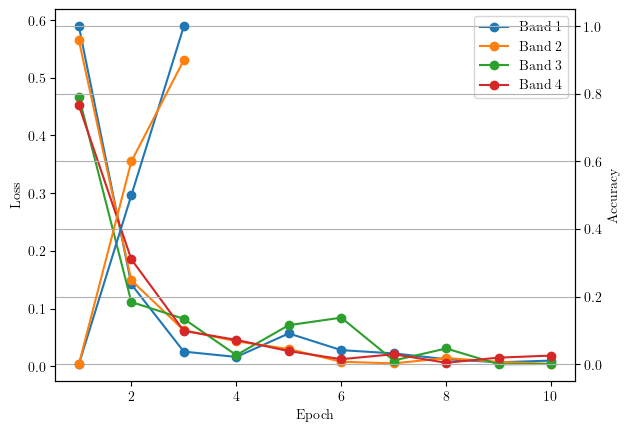

In [ ]:
#Plot loss/accuracy from kernel variables
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
for i, band_losses in enumerate(loss_history):
    ax1.plot(epochs_range, band_losses, marker='o', label=f'Band {i+1}')


ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

for i, band_accuracies in enumerate(accuracy_history):
    # print(accuracy_epochs, band_accuracies)
    ax2.plot(accuracy_epochs, band_accuracies, marker='o', label=f'Band {i+1}')

ax2.set_ylabel('Accuracy')
# plt.legend()
plt.grid(True)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

C:\Users\jacka\AppData\Local\Temp\ipykernel_50708\3411542157.py:46: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(point[0], point[1], c='b', edgecolors='k', marker='*',cmap=plt.cm.Spectral, s=100)
C:\Users\jacka\AppData\Local\Temp\ipykernel_50708\3411542157.py:48: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(point[0], point[1], c='r', edgecolors='k', marker='o',cmap=plt.cm.Spectral, s=100)


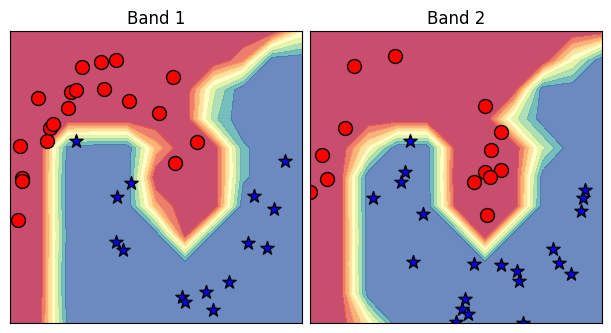

In [ ]:
#load meshgrid data and plot decision boundary


import json
import numpy as np
import matplotlib.pyplot as plt
name_of_experiment = "experiment_batching_05"

def retrieve_meshgrid_and_data(name):
    filename = f"./data_runs/{name_of_experiment}/meshgrid_data_{name}.json"
    with open(filename, "r") as f:
        data = json.load(f)

    xx = np.array(data["meshgrid"]["x"])
    yy = np.array(data["meshgrid"]["y"])
    Z = np.array(data["meshgrid"]["z"])

    X = np.array(data["data_points"]["X"])
    y = np.array(data["data_points"]["y"])

    return (xx, yy, Z, X, y)

n_bands_meshgrid = 2
xx = np.empty((n_bands_meshgrid, 11, 11))
yy = np.empty((n_bands_meshgrid, 11, 11))
Z = np.empty((n_bands_meshgrid, 11, 11))
X_meshgrid = np.empty((n_bands_meshgrid, 35, 2))
y_meshgrid = np.empty((n_bands_meshgrid, 35))

fig, axes = plt.subplots(n_bands_meshgrid // 2, 2, figsize = (6, 6), constrained_layout=True)
for i, ax in enumerate(axes.flat):
    xx[i], yy[i], Z[i], X_meshgrid[i], y_meshgrid[i] = retrieve_meshgrid_and_data(f"Band {i+1}")


z_min = Z.min()
z_max = Z.max()
# Shared contour levels
levels = np.linspace(Z.min(), Z.max(), 10)


cf = None
for i, ax in enumerate(axes.flat):
    cf = ax.contourf(xx[i], yy[i], Z[i], levels=levels, alpha=0.8, cmap=plt.cm.Spectral)
    for idx, point in enumerate(X_meshgrid[i]):
        if y_meshgrid[i,idx] == 1:
            ax.scatter(point[0], point[1], c='b', edgecolors='k', marker='*',cmap=plt.cm.Spectral, s=100)
        else:
            ax.scatter(point[0], point[1], c='r', edgecolors='k', marker='o',cmap=plt.cm.Spectral, s=100)
    ax.set_title(f'Band {i+1}')
    ax.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
    ax.set_aspect('equal', adjustable='box')

# cbar = fig.colorbar(
#     cf,          # either cf1 or cf2 is fine since levels are identical
#     ax=list(axes.ravel()),  # all axes
#     shrink=0.9
#     )
# cbar.set_label("tanh of model output")
# plt.tight_layout()
plt.savefig(f"./figures/{name_of_experiment}_boundaries.pdf", format="pdf", bbox_inches="tight")
plt.show()


C:\Users\jacka\AppData\Local\Temp\ipykernel_50708\2840328416.py:52: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(point[0], point[1], c='r', edgecolors='k', marker='o',cmap=plt.cm.Spectral, s=100)
C:\Users\jacka\AppData\Local\Temp\ipykernel_50708\2840328416.py:50: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(point[0], point[1], c='b', edgecolors='k', marker='*',cmap=plt.cm.Spectral, s=100)


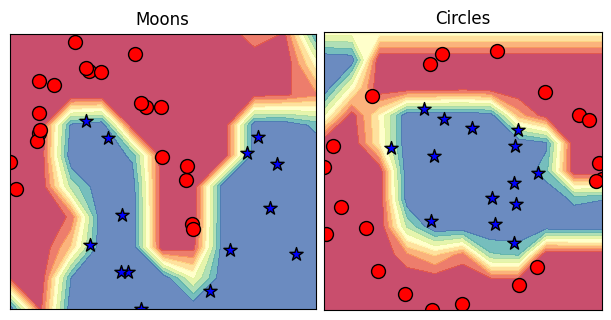

In [ ]:
#Boundary plotting (multitask setup)

import json
import numpy as np
import matplotlib.pyplot as plt
name_of_experiment = "experiment_dual_06"

def retrieve_meshgrid_and_data(name):
    filename = f"./data_runs/{name_of_experiment}/meshgrid_data_{name}.json"
    with open(filename, "r") as f:
        data = json.load(f)

    xx = np.array(data["meshgrid"]["x"])
    yy = np.array(data["meshgrid"]["y"])
    Z = np.array(data["meshgrid"]["z"])

    X = np.array(data["data_points"]["X"])
    y = np.array(data["data_points"]["y"])

    return (xx, yy, Z, X, y)

n_bands_meshgrid = 2
xx = np.empty((n_bands_meshgrid, 11, 11))
yy = np.empty((n_bands_meshgrid, 11, 11))
Z = np.empty((n_bands_meshgrid, 11, 11))
X_meshgrid = np.empty((n_bands_meshgrid, 35, 2))
y_meshgrid = np.empty((n_bands_meshgrid, 35))

fig, axes = plt.subplots(n_bands_meshgrid // 2, 2, figsize = (6, 6), constrained_layout=True, gridspec_kw={"width_ratios": [11, 10]})
# for i, ax in enumerate(axes.flat):
#     xx[i], yy[i], Z[i], X_meshgrid[i], y_meshgrid[i] = retrieve_meshgrid_and_data(f"Band {i+1}")
xx[0,:-1], yy[0,:-1], Z[0,:-1], X_meshgrid[0], y_meshgrid[0] = retrieve_meshgrid_and_data(f"Moons")
xx[1], yy[1], Z[1], X_meshgrid[1], y_meshgrid[1] = retrieve_meshgrid_and_data(f"Circles")

z_min = Z.min()
z_max = Z.max()
# Shared contour levels
levels = np.linspace(Z.min(), Z.max(), 10)


cf = None
for i, ax in enumerate(axes.flat):
    
    if i==0:
        cf = ax.contourf(xx[i,:-1], yy[i,:-1], Z[i,:-1], levels=levels, alpha=0.8, cmap=plt.cm.Spectral)
    else:
        cf = ax.contourf(xx[i], yy[i], Z[i], levels=levels, alpha=0.8, cmap=plt.cm.Spectral)
    for idx, point in enumerate(X_meshgrid[i]):
        if y_meshgrid[i,idx] == 1:
            ax.scatter(point[0], point[1], c='b', edgecolors='k', marker='*',cmap=plt.cm.Spectral, s=100)
        else:
            ax.scatter(point[0], point[1], c='r', edgecolors='k', marker='o',cmap=plt.cm.Spectral, s=100)
    ax.set_title('Moons' if i==0 else 'Circles')
    ax.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
    ax.set_aspect('equal', adjustable='box')

# cbar = fig.colorbar(
#     cf,          # either cf1 or cf2 is fine since levels are identical
#     ax=list(axes.ravel()),  # all axes
#     shrink=0.9
#     )
# cbar.set_label("tanh of model output")
# plt.tight_layout()
plt.savefig(f"./figures/{name_of_experiment}_boundaries.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [ ]:
# Load model and perform accuracy evaluation and decision boundary plotting
# Even after complete recoupling, pump WL change, and recalibration of intensities/phases, performance remains high
# TODO update this code for refactored multiband operation if it is needed again

def save_meshgrid_and_data(xx, yy, Z, X, y, model_name):
    """
    Save the meshgrid (xx, yy), decision boundary values (Z), and dataset (X, y) to a JSON file.
    
    Parameters:
        xx (np.ndarray): Meshgrid values for x-coordinates.
        yy (np.ndarray): Meshgrid values for y-coordinates.
        Z (np.ndarray): Decision boundary values corresponding to the meshgrid.
        X (torch.Tensor): Input dataset points.
        y (torch.Tensor): Labels corresponding to dataset points.
        model_name (str): Name of the model.
    """
    data_dict = {
        "meshgrid": {
            "x": xx.tolist(),
            "y": yy.tolist(),
            "z": Z.tolist()
        },
        "data_points": {
            "X": X.tolist(),
            "y": y.tolist()
        }
    }

    filename=f"./data_runs/{name_of_experiment}/meshgrid_data_{model_name}.json"

    with open(filename, "w") as f:
        json.dump(data_dict, f, indent=4)

    print(f"Meshgrid and data points saved to {filename}")

# Example usage within your function
def plot_decision_boundary(X_A, y_A, X_B, y_B, model, epoch, normalizationA, normalizationB, nameA, nameB, save_meshgrid = False):
    # Create meshgrids for both datasets
    x_min, x_max = min(X_A[:, 0].min(), X_B[:,0].min()), max(X_A[:, 0].max(), X_B[:,0].max()) + 0.2
    y_min, y_max = min(X_A[:, 1].min(), X_B[:,1].min()), max(X_A[:, 1].max(), X_B[:,1].max()) + 0.2
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.2),
                             np.arange(y_min, y_max, 0.2))
    

    
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.tensor(grid, dtype=torch.float32)
    

    Z_A = np.empty(grid_tensor.shape[0])
    Z_B = np.empty(grid_tensor.shape[0])
    
    with torch.no_grad():
        # Evaluate both models together on their respective grids
        for point_idx in range(grid_tensor.shape[0]):
            out_A, out_B = model(grid_tensor[point_idx], grid_tensor[point_idx], normalizationA, normalizationB)
            z_value_A = torch.tanh(out_A)
            z_value_B = torch.tanh(out_B)
            Z_A[point_idx] = z_value_A.item()
            Z_B[point_idx] = z_value_B.item()
        
    Z_A = Z_A.reshape(xx.shape)
    Z_B = Z_B.reshape(xx.shape)

    # Save meshgrid and data points for both models
    if save_meshgrid:
        save_meshgrid_and_data(xx, yy, Z_A, X_A, y_A, nameA)
        save_meshgrid_and_data(xx, yy, Z_B, X_B, y_B, nameB)
    
    z_min = min(Z_A.min(), Z_B.min())
    z_max = max(Z_A.max(), Z_B.max())
    # Shared contour levels
    levels = np.linspace(z_min, z_max, 10)

    # Plotting with subplots - both models side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    
    # Plot Model A (Make Moons)
    cf1 = ax1.contourf(xx, yy, Z_A, levels=levels,alpha=0.8, cmap=plt.cm.Spectral)
    ax1.scatter(X_A[:, 0], X_A[:, 1], c=y_A, edgecolors='k', cmap=plt.cm.Spectral)
    ax1.set_title(f'{nameA} - Epoch {epoch}')
    
    # Plot Model B (Make Circles)
    ax2.contourf(xx, yy, Z_B, levels=levels,alpha=0.8, cmap=plt.cm.Spectral)
    ax2.scatter(X_B[:, 0], X_B[:, 1], c=y_B, edgecolors='k', cmap=plt.cm.Spectral)
    ax2.set_title(f'{nameB} - Epoch {epoch}')
    cbar = fig.colorbar(
        cf1,          # either cf1 or cf2 is fine since levels are identical
        ax=[ax1, ax2],
        shrink=0.9
        )
    cbar.set_label("tanh of model output")
    # plt.tight_layout()
    plt.savefig(f'./data_runs/{name_of_experiment}/boundaries/boundary_{epoch}.png')
    plt.close()
def test(model, X_test_A, X_test_B, y_test_A, y_test_B, normalizationA, normalizationB):
    if X_test_A.shape[0] != X_test_B.shape[0]:
        raise ValueError("Testing datasets A and B must have the same number of samples.")
    predicted_classes_A = []
    predicted_classes_B = []
    with torch.no_grad():
        for data in range(X_test_A.shape[0]):
            y_pred_A, y_pred_B = model(X_test_A[data], X_test_B[data], normalizationA, normalizationB)
            y_pred_A = torch.sigmoid(y_pred_A)
            y_pred_B = torch.sigmoid(y_pred_B)
            predicted_classes_A.append(y_pred_A.item())
            predicted_classes_B.append(y_pred_B.item())
            print(f"Class: {y_test_A[data]} Predicted: {y_pred_A.item():.4f}")
            print(f"Class: {y_test_B[data]} Predicted: {y_pred_B.item():.4f}")
            print(f"...{(data+1) * 100 // X_test_A.shape[0]}%")

    # Convert to NumPy arrays
    predicted_classes_A = np.array(predicted_classes_A)
    predicted_classes_B = np.array(predicted_classes_B)
    y_test_A = y_test_A.numpy()
    y_test_B = y_test_B.numpy()

    accuracies = np.empty(n_bands)
    # Calculate accuracies
    for i in range(n_bands):
        accuracies[i] = accuracy_score()
    accuracy_A = accuracy_score((y_test_A > 0.5), (predicted_classes_A > 0.5))
    accuracy_B = accuracy_score((y_test_B > 0.5), (predicted_classes_B > 0.5))
    return accuracy_A, accuracy_B


name_of_experiment = "experiment_batching_05"

# Load the model from the checkpoint
model = Dual_Physical_NN_SHG(AstartCombline=comblines_range_A[0], AendCombline=comblines_range_A[-1], BstartCombline=comblines_range_B[0], BendCombline=comblines_range_B[-1], noise_rate=0)
checkpoint = torch.load(f'./data_runs/{name_of_experiment}/checkpoints/model_checkpoint14.pth', map_location=torch.device('cpu'))
state_dict = checkpoint['model_state_dict']
model.load_state_dict(state_dict, strict=True)


perm = torch.randperm(X_test.size(0))
X_shuffled = X_test[perm]
y_shuffled = y_test[perm]
mid = X_test.size(0) // 2

accuracy_A, accuracy_B = test(model, X_shuffled[:mid], X_shuffled[mid:], y_shuffled[:mid], y_shuffled[mid:], normalizationA, normalizationB)
print(f"Accuracy of model A: {accuracy_A * 100:.2f}%")
print(f"Accuracy of model B: {accuracy_B * 100:.2f}%")

# plot_decision_boundary(X_shuffled[:mid], y_shuffled[:mid], X_shuffled[mid:], y_shuffled[mid:], model, 1000, normalizationA, normalizationB, "Band A-Delayed", "Band B-Delayed", save_meshgrid=True)


NameError: name 'Dual_Physical_NN_SHG' is not defined

Band 1:
Epoch 1: Loss = 0.5892895687903676
Epoch 2: Loss = 0.14193895448531424
Epoch 3: Loss = 0.025282816948103054
Epoch 4: Loss = 0.016020337927953474
Epoch 5: Loss = 0.056805688722358486
Epoch 6: Loss = 0.027821352157999562
Epoch 7: Loss = 0.02222048352663738
Epoch 8: Loss = 0.012074214591848431
Epoch 9: Loss = 0.006768571818507293
Epoch 10: Loss = 0.009714019323967347
Band 2:
Epoch 1: Loss = 0.564999292578016
Epoch 2: Loss = 0.14875859152525664
Epoch 3: Loss = 0.062322730205154844
Epoch 4: Loss = 0.043205177750704545
Epoch 5: Loss = 0.02972025719936937
Epoch 6: Loss = 0.00766084495137745
Epoch 7: Loss = 0.0048609349185426256
Epoch 8: Loss = 0.014144534911611117
Epoch 9: Loss = 0.0074596977575440955
Epoch 10: Loss = 0.004080717657416244
Band 3:
Epoch 1: Loss = 0.46753912355218613
Epoch 2: Loss = 0.11125890426337719
Epoch 3: Loss = 0.08210505278381919
Epoch 4: Loss = 0.01918500069462295
Epoch 5: Loss = 0.07114492349792272
Epoch 6: Loss = 0.08415072635231939
Epoch 7: Loss = 0.00987127

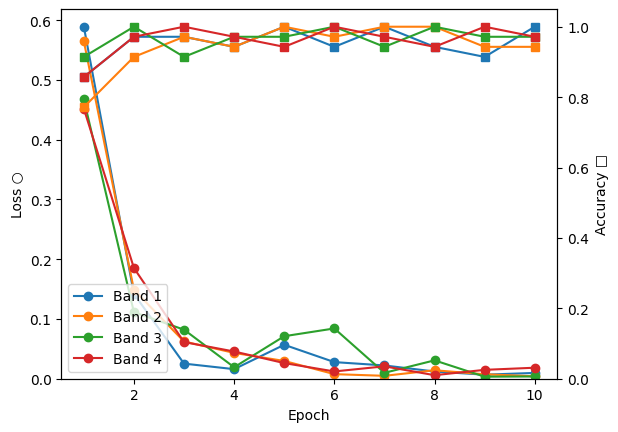

In [5]:
#Load loss/accuracy data from checkpoint and plot

import torch
import os
import matplotlib.colors as mcolors
import numpy as np

# def darken(color, factor=0.9):
#     rgb = np.array(mcolors.to_rgb(color))
#     return tuple(rgb * factor)

base_a = "tab:blue"
base_b = "tab:orange"

name_of_experiment = 'experiment_quad_01'
n_bands_lossplotting = 4
# Path to the directory containing the files
directory = f"./data_runs/{name_of_experiment}/checkpoints"

# Get a sorted list of checkpoint files in numerical order
file_list = sorted(
    [f for f in os.listdir(directory) if f.startswith("model_checkpoint") and f.endswith(".pth")],
    key=lambda x: int(x.split("checkpoint")[1].split(".pth")[0])
)
# Initialize a list to store the losses
losses = [[] for _ in range(n_bands_lossplotting)]
accuracies = [[] for _ in range(n_bands_lossplotting)]

# Loop through all the checkpoint files in the directory
for filename in file_list:
    if filename.endswith('.pth'):
        # Construct the full file path
        file_path = os.path.join(directory, filename)
        
        # Load the checkpoint
        checkpoint = torch.load(file_path, weights_only=False)
        epoch = checkpoint['epoch'] + 1
        # Extract the loss value (assuming it is stored with the key 'loss')
        if 'band_losses' in checkpoint:
            band_losses = checkpoint['band_losses']
            for i in range(n_bands_lossplotting):
                losses[i].append((epoch, band_losses[i]))
        else:
            print(f"Losses not found in {filename}")
        
        if 'accuracies' in checkpoint:
            band_accuracies = checkpoint['accuracies']
            for i in range(n_bands_lossplotting):
                accuracies[i].append((epoch, band_accuracies[i]))
        else:
            print(f"Accuracies not found in {filename}")

        
# Print the extracted losses
for idx, band_losses in enumerate(losses):
    print(f"Band {idx+1}:")
    for epoch, loss in band_losses:
        print(f"Epoch {epoch}: Loss = {loss}")


# Print the extracted accuracies
for idx, band_accuracies in enumerate(accuracies):
    print(f"Band {idx+1}:")
    for epoch, accuracy in band_losses:
        print(f"Epoch {epoch}: Accuracy = {accuracy}")

# Optional: Plot the losses for visualization
import matplotlib.pyplot as plt
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()


# Extracting just the loss values for plotting
for i in range(n_bands_lossplotting):
    ax1.plot(*zip(*losses[i]), marker='o', label=f"Band {i+1}")
    ax2.plot(*zip(*accuracies[i]), marker='s', label=f"Band {i+1}")
ax1.legend(loc='lower left')
ax1.set_ylim(bottom=0)
ax1.set_xlabel("Epoch")
# plt.title("Loss vs Epoch")
# plt.ylabel("Loss")
ax1.set_ylabel("Loss ○")
# plt.grid(True)

# plt.savefig(f"./figures/{name_of_experiment}_losses.pdf", format="pdf", bbox_inches="tight")
# plt.show()


# ax2.xlim(left=1)
ax2.set_ylim(top=1.05, bottom=0)
# plt.title("Accuracy vs Epoch")
# plt.xlabel("Epoch")
ax2.set_ylabel("Accuracy □")

# plt.grid(True)

plt.savefig(f"./figures/{name_of_experiment}_joint.pdf", format="pdf", bbox_inches="tight")
plt.show()


Accuracy A not found in model_checkpoint0.pth
Accuracy B not found in model_checkpoint0.pth
Accuracy A not found in model_checkpoint1.pth
Accuracy B not found in model_checkpoint1.pth
Accuracy A not found in model_checkpoint2.pth
Accuracy B not found in model_checkpoint2.pth
Accuracy A not found in model_checkpoint3.pth
Accuracy B not found in model_checkpoint3.pth
Accuracy A not found in model_checkpoint5.pth
Accuracy B not found in model_checkpoint5.pth
Accuracy A not found in model_checkpoint6.pth
Accuracy B not found in model_checkpoint6.pth
Accuracy A not found in model_checkpoint7.pth
Accuracy B not found in model_checkpoint7.pth
Accuracy A not found in model_checkpoint8.pth
Accuracy B not found in model_checkpoint8.pth
Accuracy A not found in model_checkpoint10.pth
Accuracy B not found in model_checkpoint10.pth
Accuracy A not found in model_checkpoint11.pth
Accuracy B not found in model_checkpoint11.pth
Accuracy A not found in model_checkpoint12.pth
Accuracy B not found in model

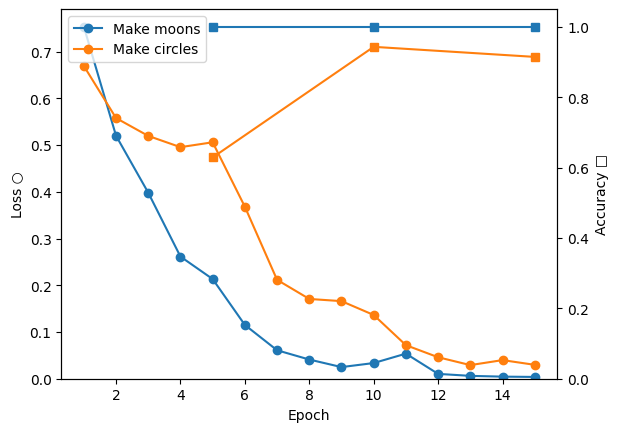

In [ ]:
#loss/accuracy plotting for old experiment format
import torch
import os
import matplotlib.colors as mcolors
import numpy as np

# def darken(color, factor=0.9):
#     rgb = np.array(mcolors.to_rgb(color))
#     return tuple(rgb * factor)

base_a = "tab:blue"
base_b = "tab:orange"

name_of_experiment = 'experiment_dual_06'
# Path to the directory containing the files
directory = f"./data_runs/{name_of_experiment}/checkpoints"

# Get a sorted list of checkpoint files in numerical order
file_list = sorted(
    [f for f in os.listdir(directory) if f.startswith("model_checkpoint") and f.endswith(".pth")],
    key=lambda x: int(x.split("checkpoint")[1].split(".pth")[0])
)
# Initialize a list to store the losses
lossesA = []
lossesB = []
accuraciesA = []
accuraciesB = []
# Loop through all the checkpoint files in the directory
for filename in file_list:
    if filename.endswith('.pth'):
        # Construct the full file path
        file_path = os.path.join(directory, filename)
        
        # Load the checkpoint
        checkpoint = torch.load(file_path)
        epoch = checkpoint['epoch'] + 1
        # Extract the loss value (assuming it is stored with the key 'loss')
        if 'loss_A' in checkpoint:
            loss = checkpoint['loss_A']
            lossesA.append((filename, loss, epoch))
        else:
            print(f"LossA not found in {filename}")
        if 'loss_B' in checkpoint:
            loss = checkpoint['loss_B']
            lossesB.append((filename, loss, epoch))
        else:
            print(f"LossB not found in {filename}")

        if 'accuracy_A' in checkpoint:
            accuracy = checkpoint['accuracy_A']
            accuraciesA.append((filename, accuracy, epoch))
        else:
            print(f"Accuracy A not found in {filename}")

        if 'accuracy_B' in checkpoint:
            accuracy = checkpoint['accuracy_B']
            accuraciesB.append((filename, accuracy, epoch))
        else:
            print(f"Accuracy B not found in {filename}")

# Print the extracted losses
for filename, loss, _ in lossesA:
    print(f"{filename}: LossA = {loss}")
for filename, loss, _ in lossesB:
    print(f"{filename}: LossB = {loss}")

# Print the extracted losses
for filename, accuracy, _ in accuraciesA:
    print(f"{filename}: Accuracy = {accuracy}")
for filename, accuracy, _ in accuraciesB:
    print(f"{filename}: Accuracy = {accuracy}")

# Optional: Plot the losses for visualization
import matplotlib.pyplot as plt
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()


# Extracting just the loss values for plotting
loss_values = [(epoch, loss) for _, loss, epoch in lossesA]
ax1.plot(*zip(*loss_values), marker='o', label='Make moons')
loss_values = [(epoch, loss) for _, loss, epoch in lossesB]
ax1.plot(*zip(*loss_values), marker='o', label='Make circles')
# plt.legend()
ax1.set_ylim(bottom=0)
ax1.set_xlabel("Epoch")
# plt.title("Loss vs Epoch")
# plt.ylabel("Loss")
ax1.set_ylabel("Loss ○")
# plt.grid(True)

# plt.savefig(f"./figures/{name_of_experiment}_losses.pdf", format="pdf", bbox_inches="tight")
# plt.show()

# Extracting just the loss values for plotting
accuracy_values = [(epoch, accuracy) for _, accuracy, epoch in accuraciesA]
ax2.plot(*zip(*accuracy_values), marker='s')
accuracy_values = [(epoch, accuracy) for _, accuracy, epoch in accuraciesB]
ax2.plot(*zip(*accuracy_values), marker='s')
# plt.legend()
# ax2.xlim(left=1)
ax2.set_ylim(top=1.05, bottom=0)
# plt.title("Accuracy vs Epoch")
# plt.xlabel("Epoch")
ax2.set_ylabel("Accuracy □")



# ------------- including results of sim in the plot --------------


# name_of_experiment = 'experiment_batching_sim_05'
# # Path to the directory containing the files
# directory = f"./data_runs/{name_of_experiment}/checkpoints"

# # Get a sorted list of checkpoint files in numerical order
# file_list = sorted(
#     [f for f in os.listdir(directory) if f.startswith("model_checkpoint") and f.endswith(".pth")],
#     key=lambda x: int(x.split("checkpoint")[1].split(".pth")[0])
# )
# # Initialize a list to store the losses
# lossesAvg = []
# # Loop through all the checkpoint files in the directory
# for filename in file_list:
#     if filename.endswith('.pth'):
#         # Construct the full file path
#         file_path = os.path.join(directory, filename)
        
#         # Load the checkpoint
#         checkpoint = torch.load(file_path)
#         epoch = checkpoint['epoch'] + 1
#         # Extract the loss value (assuming it is stored with the key 'loss')
#         if 'loss_A' in checkpoint and 'loss_B' in checkpoint:
#             loss = (checkpoint['loss_A'] + checkpoint['loss_B']) / 2
#             lossesAvg.append((filename, loss, epoch))
#         else:
#             print(f"LossA not found in {filename}")

# # Print the extracted losses
# for filename, loss, _ in lossesAvg:
#     print(f"{filename}: LossAvg = {loss}")


# # Extracting just the loss values for plotting
# loss_values = [(epoch, loss) for _, loss, epoch in lossesAvg]
# ax1.plot(*zip(*loss_values), marker='o', label = 'No SFG')

ax1.legend(loc='upper left')

# plt.savefig(f"./figures/{name_of_experiment}_joint.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [ ]:
# === Disconnect ===
disconnect_delete_waveshaper()
osa.close_connection()

Disconnecting from waveshaper...   success
Deliting waveshaper...   success
Connection closed


In [ ]:
import torch

# Load the .pth file
checkpoint = torch.load(f'./data_runs/{name_of_experiment}/checkpoints/model_checkpoint10.pth', map_location=torch.device('cpu'))
print(type(checkpoint))
checkpoint['model_state_dict']


<class 'dict'>


C:\Users\ws-server\AppData\Local\Temp\ipykernel_10156\2629051906.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(f'./data_runs/{name_of_experimen

OrderedDict([('alpha',
              tensor([-0.0125, -0.0176, -0.0232, -0.0183, -0.0027, -0.0443, -0.0145, -0.2646,
                      -0.0248, -0.5596,  0.1471, -0.1097, -0.1492, -0.1778,  0.0481,  0.0646,
                       0.2945,  0.0266,  0.3211,  0.1230, -1.1382, -0.1040,  0.2167,  0.2027,
                       0.2118, -0.0827,  0.0591,  0.0096,  0.0081])),
             ('bias', tensor([-0.0108])),
             ('phases',
              tensor([-0.1714,  0.0290, -0.0602,  0.3793, -0.0110,  0.0763,  0.0540, -0.0922,
                      -0.6505,  0.1497,  0.5390,  3.1698, -1.0237, -0.3132,  0.2370])),
             ('fc.weight',
              tensor([[ 2.6431, -0.6957],
                      [ 2.9011, -0.4326],
                      [ 2.1585, -0.7287],
                      [ 1.7431,  0.8088],
                      [ 2.4911, -1.3772],
                      [-2.8624,  0.3889],
                      [ 2.2417,  0.9271],
                      [ 2.9565, -1.5018],
              